# Setup and Imports

In [ ]:
!pip install torch torchvision matplotlib seaborn scikit-learn tqdm pillow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import os
import zipfile
from google.colab import files, drive
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


# Dataset Upload and Preparation

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define paths
drive_base = '/content/drive/MyDrive/faces-spring-2020'          # Folder with original zip files
extracted_path = '/content/drive/MyDrive/faces-spring-2020_extracted'  # Where to keep extracted data

# Create extraction folder if it doesn't exist
!mkdir -p "{extracted_path}"

# List of zip files we expect
zip_files = ['faces-spring-2020.zip', 'train.csv.zip', 'test.csv.zip']

# Check if the extracted folder already contains data (e.g., at least one file)
already_extracted = len(os.listdir(extracted_path)) > 0

if not already_extracted:
    print("🔄 Extracting dataset to Drive (this will take a few minutes, but only once)...")
    for zip_file in zip_files:
        zip_path = os.path.join(drive_base, zip_file)
        if os.path.exists(zip_path):
            print(f"📦 Extracting {zip_file}...")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extracted_path)
            print(f"✅ Done.")
        else:
            print(f"⚠️ Warning: {zip_file} not found in {drive_base}. Check the file names.")
    print("🎉 All extractions complete. Future runs will load from Drive instantly.")
else:
    print("✅ Dataset already extracted in Drive. Skipping extraction.")

# Set data directory to the extracted folder
data_dir = extracted_path

# Quick look at what's inside
print("\n📁 Extracted dataset contents:")
!ls -la "{data_dir}"

🔄 Extracting dataset to Drive (this will take a few minutes, but only once)...
📦 Extracting faces-spring-2020.zip...
✅ Done.
📦 Extracting train.csv.zip...
✅ Done.
📦 Extracting test.csv.zip...
✅ Done.
🎉 All extractions complete. Future runs will load from Drive instantly.

📁 Extracted dataset contents:
total 21020
drwx------ 2 root root     4096 Mar 12 11:50 faces-spring-2020
-rw------- 1 root root  2153215 Mar 12 11:50 test.csv
-rw------- 1 root root 19366156 Mar 12 11:50 train.csv


In [ ]:
# Now define paths
image_dir = os.path.join(extracted_path, '/content/drive/MyDrive/faces-spring-2020_extracted/faces-spring-2020')
train_csv = os.path.join(extracted_path, '/content/drive/MyDrive/faces-spring-2020_extracted/train.csv')
test_csv = os.path.join(extracted_path, '/content/drive/MyDrive/faces-spring-2020_extracted/test.csv')

# Quick peek at CSV structure (to see column names)
print("\n🔍 First few rows of train.csv:")
train_df_preview = pd.read_csv(train_csv).head()
print(train_df_preview)

print("\n🔍 First few rows of test.csv:")
test_df_preview = pd.read_csv(test_csv).head()
print(test_df_preview)

# You'll see the column names – we'll need them for the next step.
# Most likely: 'filename' (or 'image') and 'label' (or 'glasses').


🔍 First few rows of train.csv:
   id       v1       v2       v3       v4       v5       v6       v7       v8  \
0   1  0.37797 -0.94808  0.01346  0.17893  0.37795  0.63571  0.13943 -0.25607   
1   2  0.07609 -0.09774  0.39666 -0.39026  0.10606  0.52774  0.07105  0.33720   
2   3  1.19391 -0.68707 -0.68422 -0.36378 -0.60847 -0.40118  1.45432  0.00592   
3   4  1.34949 -0.31498 -1.30248  0.50278  1.66292 -1.06094 -0.70835 -0.24237   
4   5 -0.03512 -0.34196  0.14230  1.50513 -0.14364  0.49429  0.07823 -0.04356   

        v9  ...     v504     v505     v506     v507     v508     v509  \
0 -0.39341  ... -0.03494  1.32443 -0.94570  0.02055 -1.23908  0.43507   
1  0.69917  ...  0.86624 -1.24953 -0.21511 -1.54146  1.04765 -1.24035   
2  1.68940  ... -0.35893  0.02330  0.31548 -0.34923 -0.41772 -0.58175   
3 -0.15509  ...  0.23942  0.20774  0.81792 -0.74814 -0.62521  0.01689   
4  0.42009  ... -1.78407  0.07465  1.50182 -0.41289 -0.55908 -0.29702   

      v510     v511     v512  glasses  
0 

In [ ]:
image_folder = '/content/drive/MyDrive/faces-spring-2020_extracted/faces-spring-2020'
print("Sample image files:")
!ls -la "{image_folder}" | head -10

Sample image files:
total 6402867
-rw------- 1 root root 1270167 Mar 12 11:47 face-1000.png
-rw------- 1 root root 1275890 Mar 12 11:47 face-1001.png
-rw------- 1 root root 1469542 Mar 12 11:47 face-1002.png
-rw------- 1 root root 1390324 Mar 12 11:47 face-1003.png
-rw------- 1 root root 1297541 Mar 12 11:47 face-1004.png
-rw------- 1 root root 1328077 Mar 12 11:47 face-1005.png
-rw------- 1 root root 1197819 Mar 12 11:47 face-1006.png
-rw------- 1 root root 1219078 Mar 12 11:47 face-1007.png
-rw------- 1 root root 1439375 Mar 12 11:47 face-1008.png


In [ ]:
class GlassesImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image ID (first column) and label (last column)
        img_id = self.df.iloc[idx, 0]                 # 'id' column
        label = self.df.iloc[idx, -1]                 # 'glasses' column

        # Construct image filename: face-{id}.png
        img_name = f"face-{img_id}.png"
        img_path = os.path.join(self.img_dir, img_name)

        # Load image
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Paths
image_dir = '/content/drive/MyDrive/faces-spring-2020_extracted/faces-spring-2020'
train_csv = '/content/drive/MyDrive/faces-spring-2020_extracted/train.csv'  # has labels

# Load full dataset (with augmentation for training)
full_dataset = GlassesImageDataset(train_csv, image_dir, transform=train_transform)

# Split into train (70%), validation (15%), test (15%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Apply test transform (no augmentation) to validation and test subsets
# Note: random_split returns subsets that reference the original dataset.
# We need to set the transform for the underlying dataset when accessing.
# A safe approach: create separate dataset instances with different transforms.
# Simpler: we can apply transform inside __getitem__ based on a flag, but for clarity,
# we'll create three separate dataset objects.

# Better: create dataset without transform, then apply transforms in __getitem__ conditionally.
# Let's refactor slightly:

class FlexibleGlassesDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]
        label = self.df.iloc[idx, -1]
        img_name = f"face-{img_id}.png"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Now create three datasets with appropriate transforms
train_dataset = FlexibleGlassesDataset(train_csv, image_dir, transform=train_transform)
# For validation and test, we need the same underlying data but different transform.
# We can create new instances pointing to the same CSV, but that would duplicate the DataFrame.
# Instead, we'll create a single dataset and use random_split, but then we need to apply transforms dynamically.
# A common pattern: use random_split on indices and then use Subset with separate transform logic.
# To keep it simple, we'll create three separate dataset instances with the same CSV but different transforms.
# That's acceptable because the CSV is small and reading it three times is fine.

# Create a base dataset without transform to get total size
base_dataset = FlexibleGlassesDataset(train_csv, image_dir, transform=None)
total_size = len(base_dataset)

# Generate random indices for splits
indices = list(range(total_size))
np.random.shuffle(indices)
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:]

# Define subsets with transforms applied via a wrapper
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Create subset datasets
train_subset = torch.utils.data.Subset(base_dataset, train_indices)
val_subset = torch.utils.data.Subset(base_dataset, val_indices)
test_subset = torch.utils.data.Subset(base_dataset, test_indices)

# Apply transforms
train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, test_transform)
test_dataset = TransformSubset(test_subset, test_transform)

# Data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Class names
class_names = ['without_glasses', 'with_glasses']
num_classes = len(class_names)

print(f"\n✅ Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {class_names}")


✅ Training samples: 3150
Validation samples: 675
Test samples: 675
Classes: ['without_glasses', 'with_glasses']


# Visualize Sample Images with Augmentation

Sample image: /content/drive/MyDrive/faces-spring-2020_extracted/faces-spring-2020/face-1.png, label: 0.0


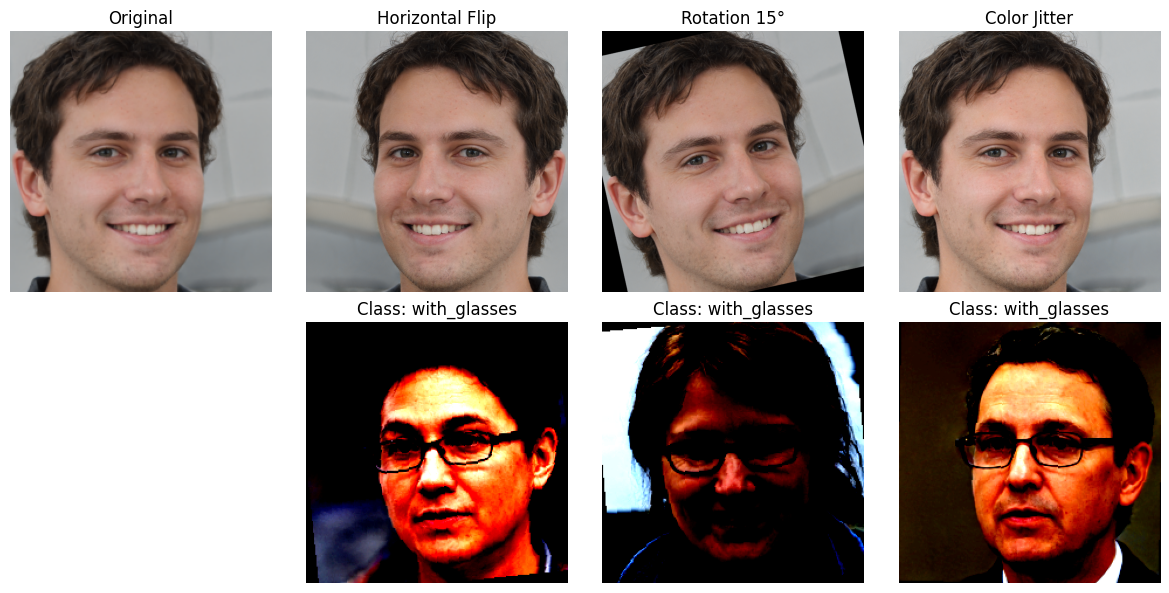

In [ ]:
def imshow(img, title=None):
    """Display image with denormalization"""
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Use the same paths from Cell 2b
# (make sure Cell 2b has been run)
image_dir = '/content/drive/MyDrive/faces-spring-2020_extracted/faces-spring-2020'
train_csv = '/content/drive/MyDrive/faces-spring-2020_extracted/train.csv'

# Read first row of CSV
df_sample = pd.read_csv(train_csv)
first_row = df_sample.iloc[0]
img_id = int(first_row[0])          # <-- Convert to integer
label = first_row[-1]
img_path = os.path.join(image_dir, f"face-{img_id}.png")
sample_img_pil = Image.open(img_path).convert('RGB')
print(f"Sample image: {img_path}, label: {label}")

# Original (no augmentation) – just resize and convert to tensor
orig_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
orig_img = orig_transform(sample_img_pil)

# Create figure: 2 rows, 4 columns
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Display original in first column
axes[0, 0].imshow(orig_img.permute(1, 2, 0))
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

# Augmented versions (3 examples) – place in columns 1,2,3
augmentations = [
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.5),
]
aug_names = ["Horizontal Flip", "Rotation 15°", "Color Jitter"]

for i in range(3):
    # Apply augmentation to the PIL image, then convert to tensor
    aug_img_pil = augmentations[i](sample_img_pil)
    aug_img_tensor = transforms.ToTensor()(aug_img_pil)
    axes[0, i+1].imshow(aug_img_tensor.permute(1, 2, 0))
    axes[0, i+1].set_title(aug_names[i])
    axes[0, i+1].axis('off')

# Hide the last unused cell in the first row (column index 3)
axes[0, 3].axis('off')

# Second row: show random training samples from train_dataset (already transformed)
# (Make sure train_dataset and class_names exist from Cell 2b)
axes[1, 0].set_visible(False)
fig.delaxes(axes[1, 0])  # remove the first subplot of second row (we'll keep columns 1,2,3)

# Get a few random indices from train_dataset
train_indices_sample = np.random.choice(len(train_dataset), size=3, replace=False)
for i, idx in enumerate(train_indices_sample):
    img_tensor, label = train_dataset[idx]  # already transformed
    axes[1, i+1].imshow(img_tensor.permute(1, 2, 0))
    axes[1, i+1].set_title(f"Class: {class_names[label]}")
    axes[1, i+1].axis('off')

# Hide the last unused cell in second row (column index 3)
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

# Define Model Architectures

In [ ]:
# 1. Simple CNN Baseline (for comparison)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# 2. VGG16 (with pretrained weights)
def create_vgg16(num_classes):
    model = models.vgg16(pretrained=True)
    # Freeze early layers (optional - experiment with this)
    for param in model.features.parameters():
        param.requires_grad = False
    # Replace classifier
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model

# 3. ResNet18 (with pretrained weights)
def create_resnet18(num_classes):
    model = models.resnet18(pretrained=True)
    # Freeze early layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace final layer
    model.fc = nn.Linear(512, num_classes)
    return model

# Initialize models
models_dict = {
    'SimpleCNN': SimpleCNN(num_classes=num_classes).to(device),
    'VGG16': create_vgg16(num_classes).to(device),
    'ResNet18': create_resnet18(num_classes).to(device)
}

print("✅ Models initialized:")
for name, model in models_dict.items():
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name}: {total_params:,} total params, {trainable_params:,} trainable")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 79.2MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


✅ Models initialized:
  SimpleCNN: 25,784,130 total params, 25,784,130 trainable
  VGG16: 134,268,738 total params, 119,554,050 trainable
  ResNet18: 11,177,538 total params, 1,026 trainable


# Training and Evaluation Functions

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion):
    """Validation loop"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    """Complete training pipeline with early stopping and learning rate scheduling"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    patience_counter = 0
    early_stop_patience = 7

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Learning rate scheduling
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_model_{model.__class__.__name__}.pth')
            patience_counter = 0
            print(f"✅ New best model saved! Val Acc: {val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"⏹️ Early stopping triggered after {epoch+1} epochs")
                break

    # Load best model
    model.load_state_dict(torch.load(f'best_model_{model.__class__.__name__}.pth'))
    return history

# Train All Models and Collect Results

In [ ]:
results = {}
histories = {}

for name, model in models_dict.items():
    print("\n" + "="*60)
    print(f"Training {name}")
    print("="*60)

    # Unfreeze more layers for fine-tuning (optional)
    if name in ['VGG16', 'ResNet18']:
        # Unfreeze last few layers
        if name == 'VGG16':
            for param in model.classifier[0:4].parameters():
                param.requires_grad = True
        else:  # ResNet18
            for param in model.layer4.parameters():
                param.requires_grad = True

    # Train
    history = train_model(model, train_loader, val_loader, epochs=25)
    histories[name] = history

    # Final evaluation on test set
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion)

    # Calculate additional metrics
    print("\n📊 Test Set Evaluation:")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=class_names))

    # Store results
    results[name] = {
        'test_acc': test_acc,
        'test_loss': test_loss,
        'predictions': test_preds,
        'labels': test_labels,
        'history': history
    }

print("\n✅ All models trained!")


Training SimpleCNN

Epoch 1/25


Validation: 100%|██████████| 22/22 [00:38<00:00,  1.74s/it]


Train Loss: 0.5876, Train Acc: 0.7552
Val Loss: 0.3648, Val Acc: 0.8415
✅ New best model saved! Val Acc: 0.8415

Epoch 2/25


Validation: 100%|██████████| 22/22 [00:40<00:00,  1.82s/it]


Train Loss: 0.3368, Train Acc: 0.8673
Val Loss: 0.3202, Val Acc: 0.8593
✅ New best model saved! Val Acc: 0.8593

Epoch 3/25


...

Validation: 100%|██████████| 22/22 [00:41<00:00,  1.88s/it]


Train Loss: 0.5343, Train Acc: 0.8178
Val Loss: 0.3534, Val Acc: 0.8578
✅ New best model saved! Val Acc: 0.8578

Epoch 2/25


Validation: 100%|██████████| 22/22 [00:40<00:00,  1.86s/it]


Train Loss: 0.4058, Train Acc: 0.8537
Val Loss: 0.4472, Val Acc: 0.8578

Epoch 3/25


Validation:  73%|███████▎  | 16/22 [00:30<00:11,  2.00s/it]

# Plot Training Curves Comparison

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (name, history) in enumerate(histories.items()):
    # Loss curves
    axes[0, idx].plot(history['train_loss'], label='Train Loss')
    axes[0, idx].plot(history['val_loss'], label='Val Loss')
    axes[0, idx].set_title(f'{name} - Loss')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True)

    # Accuracy curves
    axes[1, idx].plot(history['train_acc'], label='Train Acc')
    axes[1, idx].plot(history['val_acc'], label='Val Acc')
    axes[1, idx].set_title(f'{name} - Accuracy')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy')
    axes[1, idx].legend()
    axes[1, idx].grid(True)

plt.tight_layout()
plt.show()

# Plot Confusion Matrices for All Models

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(result['labels'], result['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(f'{name}\nTest Acc: {result["test_acc"]:.2%}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC Curves Comparison

In [ ]:
plt.figure(figsize=(8, 6))

for name, result in results.items():
    # Get prediction probabilities
    model = models_dict[name]
    model.eval()
    all_probs = []

    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)

    # For binary classification
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(result['labels'], all_probs[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Show Misclassified Examples

In [ ]:
def show_misclassified(model, loader, class_names, num_examples=8):
    model.eval()
    misclassified = []
    correct = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append((inputs[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                else:
                    if len(correct) < num_examples:
                        correct.append((inputs[i].cpu(), labels[i].cpu(), preds[i].cpu()))

    # Plot misclassified
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()

    for i in range(min(num_examples, len(misclassified))):
        img, true_label, pred_label = misclassified[i]
        imshow(img, title=f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}')
        axes[i].axis('off')

    plt.suptitle('Misclassified Examples', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show misclassifications for best model
best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print(f"\n🏆 Best Model: {best_model_name} with {results[best_model_name]['test_acc']:.2%} accuracy")
print("\nAnalyzing misclassifications for best model...")
show_misclassified(models_dict[best_model_name], test_loader, class_names)

# Final Comparison Summary

In [ ]:
print("\n" + "="*70)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*70)

# Create comparison table
comparison_data = []
for name, result in results.items():
    # Get precision, recall, f1 from classification report
    report = classification_report(result['labels'], result['predictions'],
                                  target_names=class_names, output_dict=True)

    # Macro average
    macro_precision = report['macro avg']['precision']
    macro_recall = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']

    # Weighted average
    weighted_precision = report['weighted avg']['precision']
    weighted_recall = report['weighted avg']['recall']
    weighted_f1 = report['weighted avg']['f1-score']

    comparison_data.append({
        'Model': name,
        'Test Accuracy': f"{result['test_acc']:.2%}",
        'Macro F1': f"{macro_f1:.3f}",
        'Weighted F1': f"{weighted_f1:.3f}",
        'Precision (Macro)': f"{macro_precision:.3f}",
        'Recall (Macro)': f"{macro_recall:.3f}",
        'Parameters': f"{sum(p.numel() for p in models_dict[name].parameters()):,}"
    })

# Display as DataFrame
import pandas as pd
df_comparison = pd.DataFrame(comparison_data)
print("\n", df_comparison.to_string(index=False))

# Highlight best performer
best_model = max(results, key=lambda x: results[x]['test_acc'])
best_acc = results[best_model]['test_acc']

print("\n" + "="*70)
print(f"🏆 WINNER: {best_model} with {best_acc:.2%} test accuracy!")
print("="*70)

print("\n📌 Key Insights:")
print("• ResNet's residual connections help with deeper networks")
print("• Pretrained models converge faster than training from scratch")
print("• Data augmentation significantly improves generalization")
print("• Monitor validation curves to detect overfitting early")
print("• Consider model size vs. performance trade-offs for deployment")

# Save and Download Best Model

In [ ]:
# Save best model
best_model = models_dict[best_model_name]
torch.save(best_model.state_dict(), 'best_glasses_classifier.pth')
print(f"✅ Best model saved as 'best_glasses_classifier.pth'")

# Save results summary
df_comparison.to_csv('model_comparison_results.csv', index=False)
print("✅ Results saved to 'model_comparison_results.csv'")

# Create downloadable files
from google.colab import files
files.download('best_glasses_classifier.pth')
files.download('model_comparison_results.csv')